# Creating custom K(X), coupling A(φ) and potential V(φ) models

This notebook shows how to plug your own kinetic function, conformal
coupling, or scalar potential into the K-mouflage solver **without touching
`kmouflage/models/`**.

`KModel`, `ConformalCoupling` and `Potential` (imported from
`kmouflage.models.*`) are plain dataclasses of callables. The `make_*`
factories already in `kmouflage/models/` (`make_powerlaw_K`,
`make_exponential_coupling`, ...). Any
object with the right fields works identically, wherever it's defined.

| Dataclass | Required fields | Convention |
|---|---|---|
| `KModel` | `name`, `K(X)`, `Kp(X)`, `Kpp(X)`, `u_ini(solver)`, `params` | `K(X)` = kinetic Lagrangian in the Einstein-frame variable X |
| `ConformalCoupling` | `name`, `A(φ)`, `alpha(φ)`, `alpha_phi(φ)`, `params` | `alpha = d(ln A)/dφ`, `alpha_phi = dα/dφ` |
| `Potential` | `name`, `V(φ)`, `V_phi(φ)`, `params` | optional — defaults to `V=0` if omitted |

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from kmouflage.models.k_functions import KModel, attractor_u_ini
from kmouflage.models.couplings   import ConformalCoupling
from kmouflage.models.potential   import Potential
from kmouflage.solver             import KMouflageBackground, CosmologicalParams
from kmouflage.verify             import verify

## 1. Custom K(X)

Kinetic term with an exponential (instead of power-law) correction:

$$K(X) = -1 + X + K_0 \left(e^{X/X_\star} - 1\right)$$

$$K'(X) = 1 + \frac{K_0}{X_\star} e^{X/X_\star}, \qquad
  K''(X) = \frac{K_0}{X_\star^2} e^{X/X_\star}$$

`K`, `Kp`, `Kpp` must work on both a scalar `X` and a numpy array.

`u_ini` is the initial dimensionless field velocity at `z_ini`, in the
radiation-dominated attractor regime. `attractor_u_ini` (imported above) is
generic — it only assumes `K(X) → X - 1` at leading order near `X=0`, which
holds here — so it can be reused as-is instead of deriving a new attractor
by hand.

In [2]:
def make_exp_correction_K(K0: float, X_star: float) -> KModel:
    def K(X):
        return -1.0 + X + K0 * (np.exp(np.minimum(X / X_star, 60.0)) - 1.0)

    def Kp(X):
        return 1.0 + (K0 / X_star) * np.exp(np.minimum(X / X_star, 60.0))

    def Kpp(X):
        return (K0 / X_star**2) * np.exp(np.minimum(X / X_star, 60.0))

    return KModel(
        name   = f"exp-correction (K0={K0}, X_star={X_star})",
        K      = K,
        Kp     = Kp,
        Kpp    = Kpp,
        u_ini  = attractor_u_ini,
        params = {"K0": K0, "X_star": X_star},
    )

custom_K = make_exp_correction_K(K0=1.0, X_star=200.0)

## 2. Custom coupling A(φ)

Cubic coupling instead of the built-in linear (exponential) or quadratic
(Gaussian) couplings:

$$A(\phi) = \exp\!\left(\beta\phi + \frac{\kappa}{3}\phi^3\right)$$

$$\alpha(\phi) = \frac{d\ln A}{d\phi} = \beta + \kappa\phi^2, \qquad
  \alpha_{,\phi}(\phi) = \frac{d\alpha}{d\phi} = 2\kappa\phi$$

In [3]:
def make_cubic_coupling(beta: float, kappa: float) -> ConformalCoupling:
    return ConformalCoupling(
        name      = f"cubic (β={beta}, κ={kappa})",
        A         = lambda phi: np.exp(beta * phi + (kappa / 3.0) * phi**3),
        alpha     = lambda phi: beta + kappa * phi**2,
        alpha_phi = lambda phi: 2.0 * kappa * phi,
        params    = {"beta": beta, "kappa": kappa},
    )

custom_coupling = make_cubic_coupling(beta=0.05, kappa=0.01)

## 3. Custom potential V(φ) (optional)

`potential=...` is optional — `KMouflageBackground` defaults to `V=0`. Here,
a Gaussian bump instead of the built-in exponential (monotonic) potential:

$$V(\phi) = V_0\, e^{-(\phi/\phi_\star)^2}, \qquad
  V_{,\phi}(\phi) = -\frac{2\phi}{\phi_\star^2}\,V(\phi)$$

In [4]:
def make_gaussian_potential(V0: float, phi_star: float) -> Potential:
    def V(phi):
        return V0 * np.exp(-(phi / phi_star) ** 2)

    def V_phi(phi):
        return -2.0 * phi / phi_star**2 * V(phi)

    return Potential(
        name   = f"gaussian bump (V0={V0}, phi_star={phi_star})",
        V      = V,
        V_phi  = V_phi,
        params = {"V0": V0, "phi_star": phi_star},
    )

custom_potential = make_gaussian_potential(V0=0.1, phi_star=5.0)

## 4. Run it

Nothing else changes: `KMouflageBackground` doesn't know or care whether
`model`/`coupling`/`potential` came from `kmouflage.models` or from this
notebook.

In [5]:
bg = KMouflageBackground(
    model     = custom_K,
    coupling  = custom_coupling,
    potential = custom_potential,
    cosmo     = CosmologicalParams(H0_input=67.36, Omega_m0=0.25),
)
bg.run()
verify(bg)


[RUN] z_ini=1.0e+05 | Omega_m=0.25 | Omega_r=8.4e-05
[OK] φ̃(z=0)=-5.0235e-01 | M_Pl0_eff=1.025869 | delta_Mpl=+2.5869e-02 | E_conf(z=0)=1.028450 | delta_H=+2.8450e-02

══════════════════════════════════════════════════════════════
  VERIFICATION REPORT
  Model   : exp-correction (K0=1.0, X_star=200.0)
  Coupling: cubic (β=0.05, κ=0.01)
══════════════════════════════════════════════════════════════

  Observational constraints
  ──────────────────────────────────────────────────────────────
  |ε_F| < 0.1  (BBN/G_eff)                max = +4.980e-02  [PASS]
  |α·φ̃′| ≤ 0.2·H₀  at z=0                val = +1.995e-03  [PASS]

  Numerical consistency
  ──────────────────────────────────────────────────────────────
  φ̃′ = ũ·E_conf  (conformal time)        max_rel = 9.996e-13  [PASS]

  Stability conditions
  ──────────────────────────────────────────────────────────────
  No ghost   Z_eff > 0                    min = +1.010e+00  [PASS]
  No gradient  Z > 0                      min = +1.00

False

## 5. Sanity-check plot ATTENTION changer le sanity check avec quelque petit truc

Just to show the fully custom setup integrates and post-processes exactly
like any built-in model.

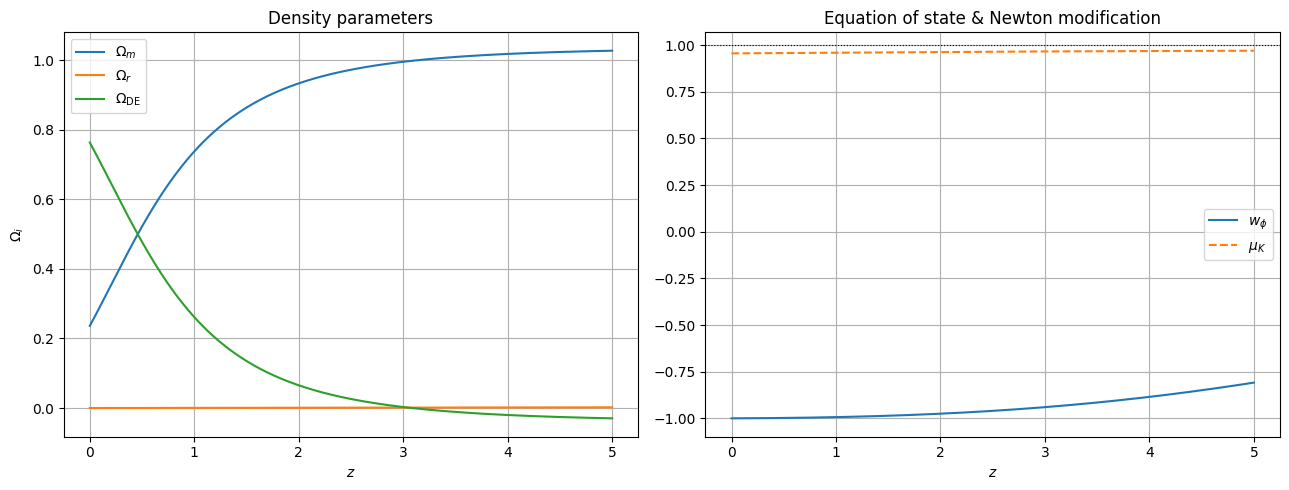

In [6]:
z = np.linspace(0, 5, 1000)
N = np.log(1.0 / (1.0 + z))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(z, bg.Omega_m(N),      label=r"$\Omega_m$")
ax.plot(z, bg.Omega_r(N),      label=r"$\Omega_r$")
ax.plot(z, bg.Omega_de_def(N), label=r"$\Omega_{\rm DE}$")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\Omega_i$")
ax.set_title("Density parameters")
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(z, bg.w_phi(N), label=r"$w_\phi$")
ax.plot(z, bg.mu_K(N),  label=r"$\mu_K$", ls="--")
ax.axhline(1, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_title("Equation of state & Newton modification")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()